In [1]:
import numpy as np
import pandas as pd
from scipy.spatial import distance_matrix
import scanpy as sc
from sklearn.neighbors import kneighbors_graph
from scipy.stats import pearsonr
import scipy
import ot
import squidpy as sq
import matplotlib.pyplot as plt

/home/kxy/miniforge3/envs/cr_39/lib/python3.9/site-packages/xarray_schema/__init__.py:1: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  from pkg_resources import DistributionNotFound, get_distribution
/home/kxy/miniforge3/envs/cr_39/lib/python3.9/site-packages/numba/core/decorators.py:246: RuntimeWarning: nopython is set for njit and is ignored
  warnings.warn('nopython is set for njit and is ignored', RuntimeWarning)


In [2]:
ad_sc=sc.read_h5ad('merfish_sc_test.h5ad')
ad_st=sc.read_h5ad('merfish_st_test.h5ad')

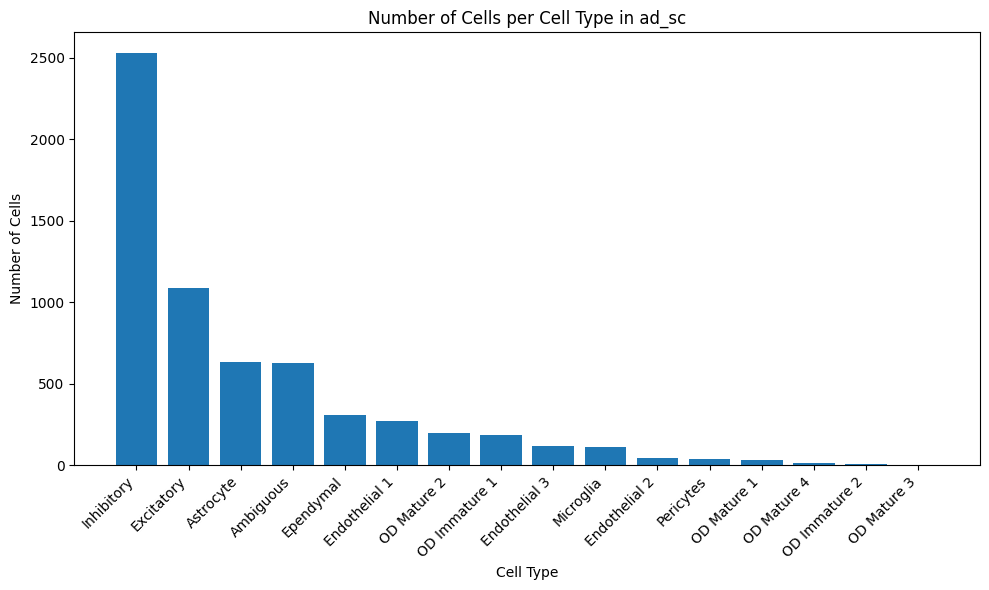

In [3]:
# Plot the number of cells in each cell type in ad_sc
cell_type_counts = ad_sc.obs['Cell_type'].value_counts()
plt.figure(figsize=(10, 6))
plt.bar(cell_type_counts.index, cell_type_counts.values)
plt.xlabel('Cell Type')
plt.ylabel('Number of Cells')
plt.title('Number of Cells per Cell Type in ad_sc')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

In [4]:
from sklearn.neighbors import NearestNeighbors
# Define the cell types of interest
target_cell_types = ['Endothelial 2', 'Pericytes', 'OD Mature 1', 'OD Mature 4', 'OD Immature 2', 'OD Mature 3']

# Filter ad_sc to get cells of the target cell types
mask = ad_sc.obs['Cell_type'].isin(target_cell_types)
target_cells = ad_sc[mask].copy()

print(f"Found {target_cells.shape[0]} cells of target cell types")
print(f"Cell type distribution:")
print(target_cells.obs['Cell_type'].value_counts())

# For each target cell, find the nearest point in ad_st spatial coordinates
nbrs_st = NearestNeighbors(n_neighbors=1, algorithm='ball_tree').fit(ad_st.obsm['spatial'])
distances, nearest_st_indices = nbrs_st.kneighbors(target_cells.obsm['spatial'])

# Create new AnnData object with the target cells
ad_sc_target = target_cells.copy()

print(f"Created ad_sc_target with shape: {ad_sc_target.shape}")

Found 126 cells of target cell types
Cell type distribution:
Cell_type
Endothelial 2    41
Pericytes        37
OD Mature 1      29
OD Mature 4      11
OD Immature 2     5
OD Mature 3       3
Name: count, dtype: int64
Created ad_sc_target with shape: (126, 161)


In [5]:
from scipy.spatial import cKDTree

# Assume ad_sc, ad_st, and target_cell_types are defined

# 1. For each spot in ad_st, find 5 closest cells in ad_sc (by spatial coordinates)
sc_coords = ad_sc.obsm["spatial"]
st_coords = ad_st.obsm["spatial"]

tree = cKDTree(sc_coords)
k = 5
# For each st spot, get indices of k nearest sc cells
distances, nearest_sc_indices = tree.query(st_coords, k=k)

# nearest_sc_indices: shape (n_spots, k)
ad_sc1_indices = np.unique(nearest_sc_indices.flatten())
ad_sc1 = ad_sc[ad_sc1_indices].copy()

# 2. For all rare cell type cells, check if they are present in ad_sc1. 
rare_mask = ad_sc.obs['Cell_type'].isin(target_cell_types)
rare_indices = np.where(rare_mask)[0]

# Names for matching
ad_sc1_names = set(ad_sc1.obs_names)
to_replace = []

for ri in rare_indices:
    rare_cell_name = ad_sc.obs_names[ri]
    if rare_cell_name not in ad_sc1_names:
        # Need to add this cell; must replace a cell in ad_sc1 with the rare cell
        # Find cell in ad_sc1 with closest spatial coords to the rare cell
        rare_coord = sc_coords[ri, :]
        ad_sc1_coords = ad_sc1.obsm['spatial']
        dists = np.linalg.norm(ad_sc1_coords - rare_coord, axis=1)
        farthest_idx = np.argmax(dists)  # Or alternatively: closest cell to rare cell to swap out
        replace_idx = np.argmin(dists)
        # Remove the closest cell, add the rare cell instead
        # In indices, ad_sc1_indices[replace_idx] is the cell to replace
        ad_sc1_indices[replace_idx] = ri
        # Update ad_sc1
        ad_sc1 = ad_sc[ad_sc1_indices].copy()
        # Update ad_sc1_names
        ad_sc1_names = set(ad_sc1.obs_names)

In [6]:
from scipy.spatial import cKDTree

# Assume ad_sc, ad_st, and target_cell_types are defined

# 1. For each spot in ad_st, find 5 closest cells in ad_sc (by spatial coordinates)
sc_coords = ad_sc.obsm["spatial"]
st_coords = ad_st.obsm["spatial"]

tree = cKDTree(sc_coords)
k = 5
# For each st spot, get indices of k nearest sc cells
distances, nearest_sc_indices = tree.query(st_coords, k=k)

# nearest_sc_indices: shape (n_spots, k)
ad_sc1_indices = np.unique(nearest_sc_indices.flatten())
ad_sc1 = ad_sc[ad_sc1_indices].copy()

# 2. For all rare cell type cells, check if they are present in ad_sc1. 
rare_mask = ad_sc.obs['Cell_type'].isin(target_cell_types)
rare_indices = np.where(rare_mask)[0]

# Names for matching
ad_sc1_names = set(ad_sc1.obs_names)
to_replace = []

for ri in rare_indices:
    rare_cell_name = ad_sc.obs_names[ri]
    if rare_cell_name not in ad_sc1_names:
        # Need to add this cell; must replace a cell in ad_sc1 with the rare cell
        # Find cell in ad_sc1 with closest spatial coords to the rare cell
        rare_coord = sc_coords[ri, :]
        ad_sc1_coords = ad_sc1.obsm['spatial']
        dists = np.linalg.norm(ad_sc1_coords - rare_coord, axis=1)
        farthest_idx = np.argmax(dists)  # Or alternatively: closest cell to rare cell to swap out
        replace_idx = np.argmin(dists)
        # Remove the closest cell, add the rare cell instead
        # In indices, ad_sc1_indices[replace_idx] is the cell to replace
        ad_sc1_indices[replace_idx] = ri
        # Update ad_sc1
        ad_sc1 = ad_sc[ad_sc1_indices].copy()
        # Update ad_sc1_names
        ad_sc1_names = set(ad_sc1.obs_names)

In [7]:
def assign_cells_to_spots(ad_sc, ad_st, max_cells_per_spot=5):
    """
    Assign cells from single-cell data to spots in spatial data using Fused Gromov-Wasserstein,
    allowing multiple cells per spot (up to max_cells_per_spot).
    
    Parameters:
    -----------
    ad_sc : AnnData
        Single-cell RNA-seq data
    ad_st : AnnData
        Spatial transcriptomics data
    max_cells_per_spot : int
        Maximum number of cells that can be assigned to each spot
        
    Returns:
    --------
    numpy.ndarray
        Array of spot indices for each cell. Length equals number of cells that were assigned.
    """
    import numpy as np
    import scipy.sparse
    import ot
    from scipy.spatial.distance import pdist, squareform, euclidean
    
    # Extract expression matrices
    sc_expr = ad_sc.X
    st_expr = ad_st.X
    
    # Convert sparse matrices to dense if needed
    if scipy.sparse.issparse(sc_expr):
        sc_expr = sc_expr.toarray()
    if scipy.sparse.issparse(st_expr):
        st_expr = st_expr.toarray()
    
    # Normalize expression data (L2 normalization for cosine similarity)
    sc_expr_norm = sc_expr / np.sqrt(np.sum(sc_expr**2, axis=1, keepdims=True) + 1e-10)
    st_expr_norm = st_expr / np.sqrt(np.sum(st_expr**2, axis=1, keepdims=True) + 1e-10)
    
    # Compute cosine similarity matrix
    similarity_matrix = np.dot(sc_expr_norm, st_expr_norm.T)
    
    # Convert to distance/cost matrix (1 - similarity) for FGW
    M = 1 - similarity_matrix
    
    n_cells = ad_sc.shape[0]
    n_spots = ad_st.shape[0]
    
    # Create uniform cost matrix for source (cells)
    C1 = np.ones((n_cells, n_cells))
    
    # Create euclidean distance cost matrix for sink (spots)
    spot_coords = ad_st.obsm['spatial']
    C2 = squareform(pdist(spot_coords, metric='euclidean'))
    
    # Create uniform distributions
    a = np.ones(n_cells) / n_cells  # source distribution
    b = np.ones(n_spots) / n_spots  # target distribution
    
    # Solve Fused Gromov-Wasserstein
    T, log = ot.gromov.fused_gromov_wasserstein(
        M, C1, C2, a, b, 
        loss_fun='square_loss',
        alpha=0.5,  # Balance between structure and feature matching
        armijo=False,
        log=True
    )
    
    # Extract assignments from the transport matrix
    # Get all transport values and sort them in descending order
    # Find non-zero transport values using vectorized operations
    non_zero_mask = T > 1e-10
    non_zero_indices = np.where(non_zero_mask)
    transport_values = list(zip(T[non_zero_mask], non_zero_indices[0], non_zero_indices[1]))
    
    transport_values.sort(reverse=True)  # Sort by transport value descending
    
    # Take the top assignments up to max_cells_per_spot * n_spots
    max_assignments = min(max_cells_per_spot * n_spots, len(transport_values))
    top_assignments = transport_values[:max_assignments]
    
    # Extract cell and spot indices
    if top_assignments:
        cell_indices = np.array([assignment[1] for assignment in top_assignments])
        spot_indices = np.array([assignment[2] for assignment in top_assignments])
    else:
        cell_indices = np.array([], dtype=int)
        spot_indices = np.array([], dtype=int)
    
    return cell_indices, spot_indices

def map_cells_to_spatial_locations(ad_sc, ad_st, max_cells_per_spot=5):
    """
    Map cells from single-cell data to spatial locations 
    that allows multiple cells per spot.
    
    Parameters:
    -----------
    ad_sc : AnnData
        Single-cell RNA-seq data
    ad_st : AnnData
        Spatial transcriptomics data
    max_cells_per_spot : int
        Maximum number of cells that can be assigned to each spot
        
    Returns:
    --------
    AnnData
        Copy of ad_sc with only the assigned cells and their spatial coordinates
    """
    # Assign cells to spots
    cell_indices, spot_indices = assign_cells_to_spots(ad_sc, ad_st, max_cells_per_spot)
    
    # If no cells were assigned, return an empty AnnData object
    if len(cell_indices) == 0:
        return ad_sc[[]].copy()
    
    # Create a copy with only the assigned cells
    ad_result = ad_sc[cell_indices].copy()
    
    # Get the spatial coordinates for the assigned spots
    spot_coords = ad_st.obsm['spatial'][spot_indices]
    
    # Assign these coordinates to the cells
    ad_result.obsm['spatial'] = spot_coords
    
    # Add a small amount of noise to avoid perfect overlaps
    n_result_cells = ad_result.shape[0]
    
    # Estimate an appropriate noise scale
    if ad_st.shape[0] > 1:
        from scipy.spatial import distance_matrix
        spot_dists = distance_matrix(ad_st.obsm['spatial'], ad_st.obsm['spatial'])
        np.fill_diagonal(spot_dists, np.inf)  # Ignore self-distances
        noise_scale = 0.05 * np.median(np.min(spot_dists, axis=1))
    else:
        noise_scale = 0.01
    
    # Add noise
    ad_result.obsm['spatial'] += np.random.normal(0, noise_scale, size=(n_result_cells, 2))
    
    return ad_result

In [8]:
ad_c=map_cells_to_spatial_locations(ad_sc1,ad_st,5)

/home/kxy/miniforge3/envs/cr_39/lib/python3.9/site-packages/anndata/_core/anndata.py:1754: UserWarning: Observation names are not unique. To make them unique, call `.obs_names_make_unique`.
  utils.warn_names_duplicates("obs")


In [9]:
# First, define the target cell types list; if it's not defined, assume an example list or require definition elsewhere.
# Example: target_cell_types = ["TypeA", "TypeB"]
# If defined elsewhere, comment this out or replace accordingly.
# target_cell_types = ["TypeA", "TypeB"]  # <-- replace as needed

import numpy as np

from scipy.spatial.distance import cdist

# 1. Get indices in ad_sc for cells with types in target_cell_types
is_target = ad_sc1.obs['Cell_type'].isin(target_cell_types)
sc_target_indices = np.where(is_target)[0]

# 2. Determine cell indices already in ad_c (relative to ad_sc)
# Since ad_c is typically a subset of ad_sc, and pandas indices might be preserved,
# safest is to use obs_names (row names)
ad_c_cell_names = set(ad_c.obs_names)
missing_indices = []

for idx in sc_target_indices:
    cell_name = ad_sc1.obs_names[idx]
    if cell_name not in ad_c_cell_names:
        missing_indices.append(idx)

if missing_indices:
    # Prepare data to append: X, obs, var match ad_sc, but spatial is determined below
    # For each missing cell, find the spot in ad_st with most similar expression
    # 1. Get expression matrices (convert sparse to dense if needed)
    from scipy.sparse import issparse
    sc_X = ad_sc1.X
    st_X = ad_st.X
    if issparse(sc_X):
        sc_X = sc_X.toarray()
    if issparse(st_X):
        st_X = st_X.toarray()
    # Indices of missing cells in ad_sc.X
    missing_expr = sc_X[missing_indices, :]
    st_expr = st_X

    # Normalize for cosine similarity (L2 across genes)
    missing_expr_norm = missing_expr / (np.linalg.norm(missing_expr, axis=1, keepdims=True) + 1e-10)
    st_expr_norm = st_expr / (np.linalg.norm(st_expr, axis=1, keepdims=True) + 1e-10)
    # Cosine similarity: dot product
    cosine_sim = np.dot(missing_expr_norm, st_expr_norm.T)
    spot_best_match = np.argmax(cosine_sim, axis=1)  # shape: (n_missing,)

    # Prepare new cells' AnnData
    # Slice rows in ad_sc for missing_indices
    from anndata import AnnData
    ad_missing = ad_sc1[missing_indices].copy()
    # Assign appropriate spatial coordinates
    ad_missing.obsm['spatial'] = ad_st.obsm['spatial'][spot_best_match]

    # Concatenate with ad_c
    from anndata import concat as anndata_concat
    ad_c1 = anndata_concat([ad_c, ad_missing], join='outer', merge='unique', axis=0)
else:
    ad_c1 = ad_c.copy()

/home/kxy/miniforge3/envs/cr_39/lib/python3.9/site-packages/anndata/_core/anndata.py:1754: UserWarning: Observation names are not unique. To make them unique, call `.obs_names_make_unique`.
  utils.warn_names_duplicates("obs")


In [10]:
noise_std = 0.01  # adjust as appropriate for your data scale
ad_c1.obsm['spatial'] = ad_c1.obsm['spatial'] + np.random.normal(
    loc=0, scale=noise_std, size=ad_c1.obsm['spatial'].shape
)

In [11]:
import numpy as np
from scipy.stats import pearsonr
from sklearn.neighbors import NearestNeighbors

m_val = 125  
U0 = 0.1 / (2.85 / m_val)
V0 = 1.1 / (2.85 / m_val)
xi1 = 1.21 / (2.85 / m_val)
xi2 = 1.9 / (2.85 / m_val)
iterations = 10
dt = .5
xsr = 75
x_r = 125

xc = ad_c1.obsm['spatial']*5000

# Find the closest spot in ad_st.obsm['spatial'] to each position in xc
nbrs = NearestNeighbors(n_neighbors=1, algorithm='ball_tree').fit(ad_st.obsm['spatial']*5000)
distances, indices = nbrs.kneighbors(xc)
xs = ad_st.obsm['spatial'][indices.flatten()]*5000

import scanpy as sc
sc.pp.pca(ad_c1)
X_sc2m2 = ad_c1.obsm['X_pca']

# For each cell in ad_c1, find the index of its nearest spot in ad_st
cell_coords = ad_c1.obsm["spatial"]*5000
spot_coords = ad_st.obsm["spatial"]*5000

nbrs = NearestNeighbors(n_neighbors=1, algorithm='ball_tree').fit(spot_coords)
_, cell_to_nearest_spot = nbrs.kneighbors(cell_coords)
cell_to_nearest_spot = cell_to_nearest_spot.flatten()  # shape: (n_cells,)

# For each spot, find the list of cell indices that map to it
x_id1 = []
for i in range(spot_coords.shape[0]):
    # Indices of cells whose nearest spot index is i
    cell_indices = np.where(cell_to_nearest_spot == i)[0]
    x_id1.append(cell_indices)

def F_gc(xi, xj, gi, gj):  # modified gene force for just attraction
    c = pearsonr(gi, gj)[0]
    if (np.linalg.norm(xi - xj) > 0) and (c > 0):
        f = c * (xi - xj) / np.linalg.norm(xi - xj)
    else:
        f = np.zeros_like(xi)
    return f

def V_xy(xi, xj, V0, U0, xi1, xi2):
    # assume xi,xj are vectors
    r2 = (xj[0] - xi[0]) ** 2 + (xj[1] - xi[1]) ** 2
    r = np.sqrt(r2)
    if r == 0:
        return np.zeros(2)
    dVdr = -2 * r * V0 / xi1 ** 2 * np.exp(-r2 / xi1 ** 2) + 2 * r / xi2 ** 2 * U0 * np.exp(-r2 / xi2 ** 2)
    drdx = (xj[0] - xi[0]) / r
    drdy = (xj[1] - xi[1]) / r
    dVdx = dVdr * drdx
    dVdy = dVdr * drdy
    return np.array([dVdx, dVdy])

def F_spot(xi, si, rS):
    # xi, si: (n_cells, 2)
    var1 = si - xi
    norms = np.linalg.norm(var1, axis=1)
    # Avoid division by zero
    norms_safe = norms + 1e-10
    f = var1 / norms_safe[:, None]
    fs = np.minimum((norms - rS) ** 2, 30)
    f[norms < rS] = 0
    return f * fs[:, None]

# Setup for dynamics
pos_s = np.tile(xs[None, :, :], (iterations + 1, 1, 1))
pos = np.tile(xc[None, :, :], (iterations + 1, 1, 1))   
F_gc_const = np.linspace(1, 0, iterations) ** 2
n_mapped = xc.shape[0]

for i in range(iterations):
    p = pos[i, :, :].copy()
    p += F_spot(pos[i, :, :], pos_s[i, :, :], x_r)  # add spot force to every cell
    for j in range(n_mapped):
        # For all cells mapped to the same spot as cell j, except self
        indices_this_spot = x_id1[cell_to_nearest_spot[j]]
        for k in indices_this_spot:
            if j != k:
                dv = V_xy(pos[i, k, :], pos[i, j, :], V0, U0, xi1, xi2)
                p[j, :] += -dt * dv
                p[j, :] += 4 * F_gc_const[i] * F_gc(pos[i, k, :], pos[i, j, :], X_sc2m2[k, :], X_sc2m2[j, :])  # gene force
    pos[i + 1, :, :] = p

/home/kxy/miniforge3/envs/cr_39/lib/python3.9/site-packages/anndata/_core/anndata.py:1754: UserWarning: Observation names are not unique. To make them unique, call `.obs_names_make_unique`.
  utils.warn_names_duplicates("obs")


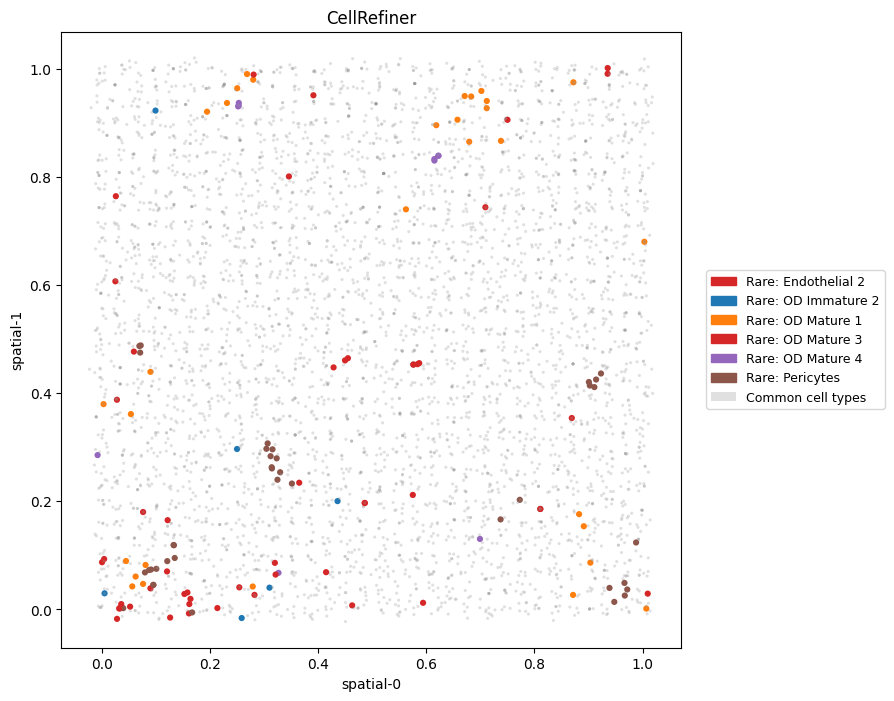

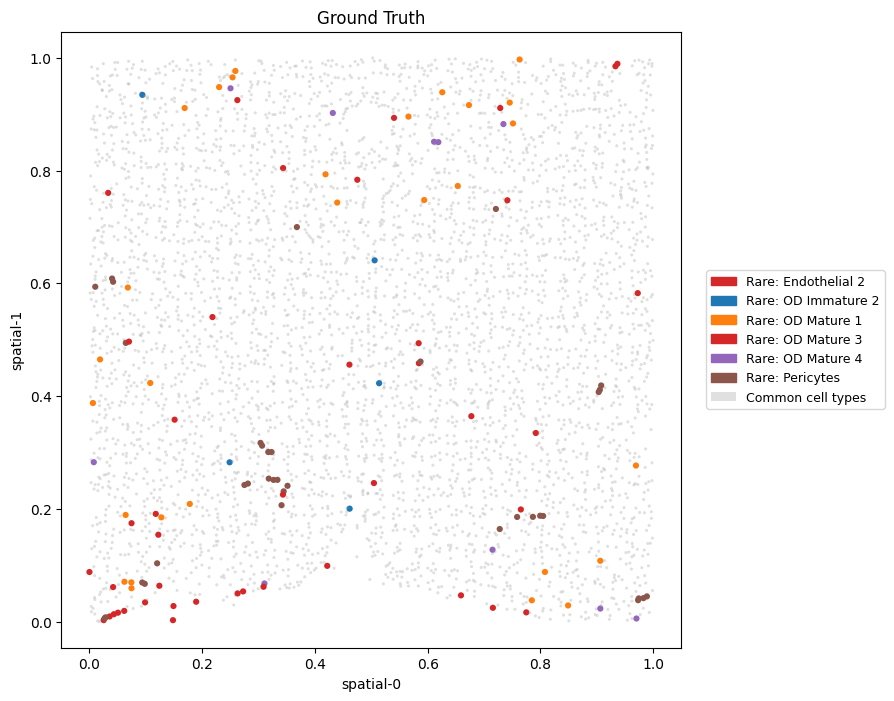

In [12]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

# Step 1: Create ad_c2 as a copy of ad_c1, replace spatial coords
ad_c2 = ad_c1.copy()
ad_c2.obsm['spatial'] = pos[-1, :, :] / 5000

# Define rare cell types explicitly as specified
RARE_CELL_TYPES = ['Endothelial 2', 'Pericytes', 'OD Mature 1', 'OD Mature 4', 'OD Immature 2', 'OD Mature 3']

# Changed colormap: now using 'tab10' instead of 'tab20'
RARE_COLOR_MAP = 'tab10'

def plot_cells_with_rare_highlight(ad, title, ax=None, return_handles=False, legend_outside=False):
    # Use explicitly defined rare cell types
    rare_cell_types = set(RARE_CELL_TYPES)
    is_rare = ad.obs['Cell_type'].isin(rare_cell_types)
    cell_type_codes = pd.Categorical(ad.obs['Cell_type']).codes
    colors = np.where(is_rare, cell_type_codes, -1)
    cmap = plt.get_cmap(RARE_COLOR_MAP)
    colormap = np.array([cmap(code % 10) if code >= 0 else (0.6, 0.6, 0.6, 0.3) for code in colors])
    sizes = np.where(is_rare, 20, 5)
    if ax is None:
        fig, ax = plt.subplots(figsize=(8, 8))
    sc = ax.scatter(
        ad.obsm['spatial'][:, 0], 
        ad.obsm['spatial'][:, 1], 
        c=colormap,
        s=sizes,
        edgecolor='none'
    )
    ax.set_title(title)
    ax.set_xlabel('spatial-0')
    ax.set_ylabel('spatial-1')
    ax.axis('equal')
    # Legend: one handle for each rare cell type, one for background (non-rare)
    handles = []
    cat = pd.Categorical(ad.obs['Cell_type'])
    present_rare_types = sorted(set(cat.categories) & rare_cell_types)
    for rare_type in present_rare_types:
        code = cat.categories.get_loc(rare_type)
        handles.append(
            mpatches.Patch(color=cmap(code % 10), label=f'Rare: {rare_type}')
        )
    handles.append(
        mpatches.Patch(facecolor=(0.6, 0.6, 0.6, 0.3), edgecolor='none', label='Common cell types')
    )
    if legend_outside:
        ax.legend(handles=handles, loc='center left', bbox_to_anchor=(1.03, 0.5), fontsize=9, frameon=True)
    else:
        ax.legend(handles=handles, loc='best', fontsize=9, frameon=True)
    if return_handles:
        return sc, handles
    return sc

# Plot for ad_c2
fig, ax = plt.subplots(figsize=(8,8))
plot_cells_with_rare_highlight(ad_c2, 'CellRefiner', ax=ax, legend_outside=True)
plt.axis('equal')
plt.show()

# Plot for ad_sc1 with same style and legend outside
fig, ax = plt.subplots(figsize=(8,8))
plot_cells_with_rare_highlight(ad_sc1, 'Ground Truth', ax=ax, legend_outside=True)
plt.axis('equal')
plt.show()


In [13]:
# For each cell type, ensure all cells from ad_sc are represented in ad_c
import pandas as pd
from sklearn.metrics.pairwise import cosine_similarity
from scipy.spatial.distance import cdist

# Get unique cell types
cell_types = ad_sc.obs['Cell_type'].unique()

# Dictionary to store results for each cell type
cell_type_results = {}

for cell_type in cell_types:
    print(f"Processing cell type: {cell_type}")
    
    # Find all cells of this type in ad_sc
    sc_cells_mask = ad_sc.obs['Cell_type'] == cell_type
    sc_cells_indices = np.where(sc_cells_mask)[0]
    
    # Find cells of this type in ad_c
    c_cells_mask = ad_c.obs['Cell_type'] == cell_type
    c_cells_indices = np.where(c_cells_mask)[0]
    
    # Create a copy of ad_c for this cell type
    ad_c_celltype = ad_c.copy()
    
    # Check which cells from ad_sc are missing in ad_c
    # We'll use the original indices to track cells
    sc_cell_names = ad_sc.obs_names[sc_cells_mask]
    c_cell_names = ad_c.obs_names[c_cells_mask]
    
    missing_cells = []
    for i, sc_idx in enumerate(sc_cells_indices):
        sc_name = ad_sc.obs_names[sc_idx]
        if sc_name not in c_cell_names:
            missing_cells.append(sc_idx)
    
    print(f"  Missing {len(missing_cells)} cells of type {cell_type}")
    
    # For each missing cell, find the best spot and replace a nearby cell
    for missing_idx in missing_cells:
        # Get gene expression of missing cell
        missing_expr = ad_sc.X[missing_idx].toarray().flatten() if hasattr(ad_sc.X, 'toarray') else ad_sc.X[missing_idx].flatten()
        
        # Calculate cosine similarity with all spots in ad_st
        st_expr = ad_st.X.toarray() if hasattr(ad_st.X, 'toarray') else ad_st.X
        similarities = cosine_similarity([missing_expr], st_expr)[0]
        
        # Find the spot with highest similarity
        best_spot_idx = np.argmax(similarities)
        best_spot_coord = ad_st.obsm['spatial'][best_spot_idx]
        
        # Find cells in ad_c that are close to this spot
        c_coords = ad_c_celltype.obsm['spatial']
        distances = cdist([best_spot_coord], c_coords)[0]
        
        # Find the closest cell in ad_c to replace
        closest_cell_idx = np.argmin(distances)
        
        # Replace the closest cell with the missing cell
        ad_c_celltype.X[closest_cell_idx] = ad_sc.X[missing_idx]
        ad_c_celltype.obs.iloc[closest_cell_idx] = ad_sc.obs.iloc[missing_idx]
        ad_c_celltype.obs_names.values[closest_cell_idx] = ad_sc.obs_names[missing_idx]
        
        # Keep the spatial coordinates of the replaced cell
        # (so the missing cell gets placed near the best matching spot)
    
    # Store the result for this cell type
    cell_type_results[cell_type] = ad_c_celltype
    print(f"  Completed processing for {cell_type}")

/home/kxy/miniforge3/envs/cr_39/lib/python3.9/site-packages/anndata/_core/anndata.py:1754: UserWarning: Observation names are not unique. To make them unique, call `.obs_names_make_unique`.
  utils.warn_names_duplicates("obs")
/home/kxy/miniforge3/envs/cr_39/lib/python3.9/site-packages/scipy/sparse/_index.py:142: SparseEfficiencyWarning: Changing the sparsity structure of a csr_matrix is expensive. lil_matrix is more efficient.
  self._set_arrayXarray_sparse(i, j, x)
/home/kxy/miniforge3/envs/cr_39/lib/python3.9/site-packages/scipy/sparse/_index.py:142: SparseEfficiencyWarning: Changing the sparsity structure of a csr_matrix is expensive. lil_matrix is more efficient.
  self._set_arrayXarray_sparse(i, j, x)
/home/kxy/miniforge3/envs/cr_39/lib/python3.9/site-packages/scipy/sparse/_index.py:142: SparseEfficiencyWarning: Changing the sparsity structure of a csr_matrix is expensive. lil_matrix is more efficient.
  self._set_arrayXarray_sparse(i, j, x)
/home/kxy/miniforge3/envs/cr_39/lib/py

Processing cell type: Microglia
  Missing 26 cells of type Microglia
  Completed processing for Microglia
Processing cell type: Astrocyte
  Missing 140 cells of type Astrocyte


/home/kxy/miniforge3/envs/cr_39/lib/python3.9/site-packages/scipy/sparse/_index.py:142: SparseEfficiencyWarning: Changing the sparsity structure of a csr_matrix is expensive. lil_matrix is more efficient.
  self._set_arrayXarray_sparse(i, j, x)
/home/kxy/miniforge3/envs/cr_39/lib/python3.9/site-packages/scipy/sparse/_index.py:142: SparseEfficiencyWarning: Changing the sparsity structure of a csr_matrix is expensive. lil_matrix is more efficient.
  self._set_arrayXarray_sparse(i, j, x)
/home/kxy/miniforge3/envs/cr_39/lib/python3.9/site-packages/scipy/sparse/_index.py:142: SparseEfficiencyWarning: Changing the sparsity structure of a csr_matrix is expensive. lil_matrix is more efficient.
  self._set_arrayXarray_sparse(i, j, x)
/home/kxy/miniforge3/envs/cr_39/lib/python3.9/site-packages/scipy/sparse/_index.py:142: SparseEfficiencyWarning: Changing the sparsity structure of a csr_matrix is expensive. lil_matrix is more efficient.
  self._set_arrayXarray_sparse(i, j, x)
/home/kxy/miniforge3

  Completed processing for Astrocyte
Processing cell type: Endothelial 1
  Missing 67 cells of type Endothelial 1
  Completed processing for Endothelial 1
Processing cell type: Endothelial 2
  Missing 1 cells of type Endothelial 2
  Completed processing for Endothelial 2
Processing cell type: Endothelial 3
  Missing 29 cells of type Endothelial 3
  Completed processing for Endothelial 3
Processing cell type: Pericytes
  Missing 1 cells of type Pericytes
  Completed processing for Pericytes
Processing cell type: Ambiguous
  Missing 149 cells of type Ambiguous


/home/kxy/miniforge3/envs/cr_39/lib/python3.9/site-packages/scipy/sparse/_index.py:142: SparseEfficiencyWarning: Changing the sparsity structure of a csr_matrix is expensive. lil_matrix is more efficient.
  self._set_arrayXarray_sparse(i, j, x)
/home/kxy/miniforge3/envs/cr_39/lib/python3.9/site-packages/scipy/sparse/_index.py:142: SparseEfficiencyWarning: Changing the sparsity structure of a csr_matrix is expensive. lil_matrix is more efficient.
  self._set_arrayXarray_sparse(i, j, x)
/home/kxy/miniforge3/envs/cr_39/lib/python3.9/site-packages/scipy/sparse/_index.py:142: SparseEfficiencyWarning: Changing the sparsity structure of a csr_matrix is expensive. lil_matrix is more efficient.
  self._set_arrayXarray_sparse(i, j, x)
/home/kxy/miniforge3/envs/cr_39/lib/python3.9/site-packages/scipy/sparse/_index.py:142: SparseEfficiencyWarning: Changing the sparsity structure of a csr_matrix is expensive. lil_matrix is more efficient.
  self._set_arrayXarray_sparse(i, j, x)
/home/kxy/miniforge3

...

/home/kxy/miniforge3/envs/cr_39/lib/python3.9/site-packages/scipy/sparse/_index.py:142: SparseEfficiencyWarning: Changing the sparsity structure of a csr_matrix is expensive. lil_matrix is more efficient.
  self._set_arrayXarray_sparse(i, j, x)
/home/kxy/miniforge3/envs/cr_39/lib/python3.9/site-packages/scipy/sparse/_index.py:142: SparseEfficiencyWarning: Changing the sparsity structure of a csr_matrix is expensive. lil_matrix is more efficient.
  self._set_arrayXarray_sparse(i, j, x)
/home/kxy/miniforge3/envs/cr_39/lib/python3.9/site-packages/scipy/sparse/_index.py:142: SparseEfficiencyWarning: Changing the sparsity structure of a csr_matrix is expensive. lil_matrix is more efficient.
  self._set_arrayXarray_sparse(i, j, x)
/home/kxy/miniforge3/envs/cr_39/lib/python3.9/site-packages/scipy/sparse/_index.py:142: SparseEfficiencyWarning: Changing the sparsity structure of a csr_matrix is expensive. lil_matrix is more efficient.
  self._set_arrayXarray_sparse(i, j, x)
/home/kxy/miniforge3

  Completed processing for Excitatory
Processing cell type: OD Immature 1
  Missing 44 cells of type OD Immature 1
  Completed processing for OD Immature 1
Processing cell type: OD Mature 2
  Missing 42 cells of type OD Mature 2
  Completed processing for OD Mature 2
Processing cell type: OD Mature 4
  Missing 1 cells of type OD Mature 4
  Completed processing for OD Mature 4
Processing cell type: OD Mature 3
  Missing 0 cells of type OD Mature 3
  Completed processing for OD Mature 3
Processing cell type: OD Immature 2
  Missing 0 cells of type OD Immature 2
  Completed processing for OD Immature 2
Processing cell type: Ependymal
  Missing 132 cells of type Ependymal


/home/kxy/miniforge3/envs/cr_39/lib/python3.9/site-packages/scipy/sparse/_index.py:142: SparseEfficiencyWarning: Changing the sparsity structure of a csr_matrix is expensive. lil_matrix is more efficient.
  self._set_arrayXarray_sparse(i, j, x)
/home/kxy/miniforge3/envs/cr_39/lib/python3.9/site-packages/scipy/sparse/_index.py:142: SparseEfficiencyWarning: Changing the sparsity structure of a csr_matrix is expensive. lil_matrix is more efficient.
  self._set_arrayXarray_sparse(i, j, x)
/home/kxy/miniforge3/envs/cr_39/lib/python3.9/site-packages/scipy/sparse/_index.py:142: SparseEfficiencyWarning: Changing the sparsity structure of a csr_matrix is expensive. lil_matrix is more efficient.
  self._set_arrayXarray_sparse(i, j, x)
/home/kxy/miniforge3/envs/cr_39/lib/python3.9/site-packages/scipy/sparse/_index.py:142: SparseEfficiencyWarning: Changing the sparsity structure of a csr_matrix is expensive. lil_matrix is more efficient.
  self._set_arrayXarray_sparse(i, j, x)
/home/kxy/miniforge3

  Completed processing for Ependymal


/home/kxy/miniforge3/envs/cr_39/lib/python3.9/site-packages/scipy/sparse/_index.py:142: SparseEfficiencyWarning: Changing the sparsity structure of a csr_matrix is expensive. lil_matrix is more efficient.
  self._set_arrayXarray_sparse(i, j, x)
/home/kxy/miniforge3/envs/cr_39/lib/python3.9/site-packages/scipy/sparse/_index.py:142: SparseEfficiencyWarning: Changing the sparsity structure of a csr_matrix is expensive. lil_matrix is more efficient.
  self._set_arrayXarray_sparse(i, j, x)
/home/kxy/miniforge3/envs/cr_39/lib/python3.9/site-packages/scipy/sparse/_index.py:142: SparseEfficiencyWarning: Changing the sparsity structure of a csr_matrix is expensive. lil_matrix is more efficient.
  self._set_arrayXarray_sparse(i, j, x)
/home/kxy/miniforge3/envs/cr_39/lib/python3.9/site-packages/scipy/sparse/_index.py:142: SparseEfficiencyWarning: Changing the sparsity structure of a csr_matrix is expensive. lil_matrix is more efficient.
  self._set_arrayXarray_sparse(i, j, x)
/home/kxy/miniforge3

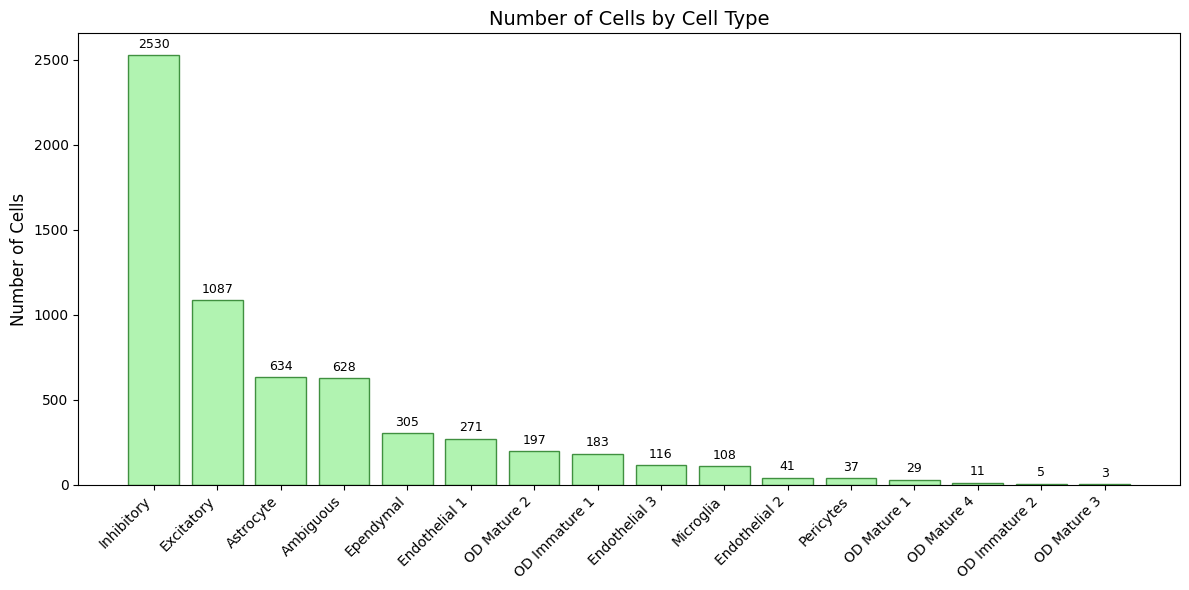


Cell type distribution in ad_sc:
  Inhibitory: 2530 cells
  Excitatory: 1087 cells
  Astrocyte: 634 cells
  Ambiguous: 628 cells
  Ependymal: 305 cells
  Endothelial 1: 271 cells
  OD Mature 2: 197 cells
  OD Immature 1: 183 cells
  Endothelial 3: 116 cells
  Microglia: 108 cells
  Endothelial 2: 41 cells
  Pericytes: 37 cells
  OD Mature 1: 29 cells
  OD Mature 4: 11 cells
  OD Immature 2: 5 cells
  OD Mature 3: 3 cells

Total cells: 6185


In [24]:
# Create a graph showing the number of cells in each cell type in ad_sc
plt.figure(figsize=(12, 6))

# Count cells by cell type
cell_type_counts = ad_sc.obs['Cell_type'].value_counts()

# Create bar plot
bars = plt.bar(cell_type_counts.index, cell_type_counts.values, 
               alpha=0.7, color='lightgreen', edgecolor='darkgreen')

# plt.xlabel('Cell Type', fontsize=12)
plt.ylabel('Number of Cells', fontsize=12)
plt.title('Number of Cells by Cell Type', fontsize=14)
plt.xticks(rotation=45, ha='right')

# Add value labels on bars
for bar, count in zip(bars, cell_type_counts.values):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + max(cell_type_counts.values)*0.01,
             f'{count}', ha='center', va='bottom', fontsize=9)

plt.tight_layout()
if enable_save:
    plt.savefig('Number of Cells.png', dpi=500, bbox_inches='tight')
plt.show()

# Print summary
print(f"\nCell type distribution in ad_sc:")
for cell_type, count in cell_type_counts.items():
    print(f"  {cell_type}: {count} cells")
print(f"\nTotal cells: {len(ad_sc)}")

Calculating error for Microglia...
  Average error for Microglia: 0.493 (based on 81 cells)
Calculating error for Astrocyte...
  Average error for Astrocyte: 0.458 (based on 488 cells)
Calculating error for Endothelial 1...
  Average error for Endothelial 1: 0.453 (based on 206 cells)
Calculating error for Endothelial 2...
  Average error for Endothelial 2: 0.259 (based on 37 cells)
Calculating error for Endothelial 3...
  Average error for Endothelial 3: 0.456 (based on 90 cells)
Calculating error for Pericytes...
  Average error for Pericytes: 0.287 (based on 36 cells)
Calculating error for Ambiguous...
  Average error for Ambiguous: 0.366 (based on 520 cells)
Calculating error for Inhibitory...
  Average error for Inhibitory: 0.305 (based on 1784 cells)
Calculating error for OD Mature 1...
  Average error for OD Mature 1: 0.472 (based on 29 cells)
Calculating error for Excitatory...
  Average error for Excitatory: 0.280 (based on 833 cells)
Calculating error for OD Immature 1...
  A

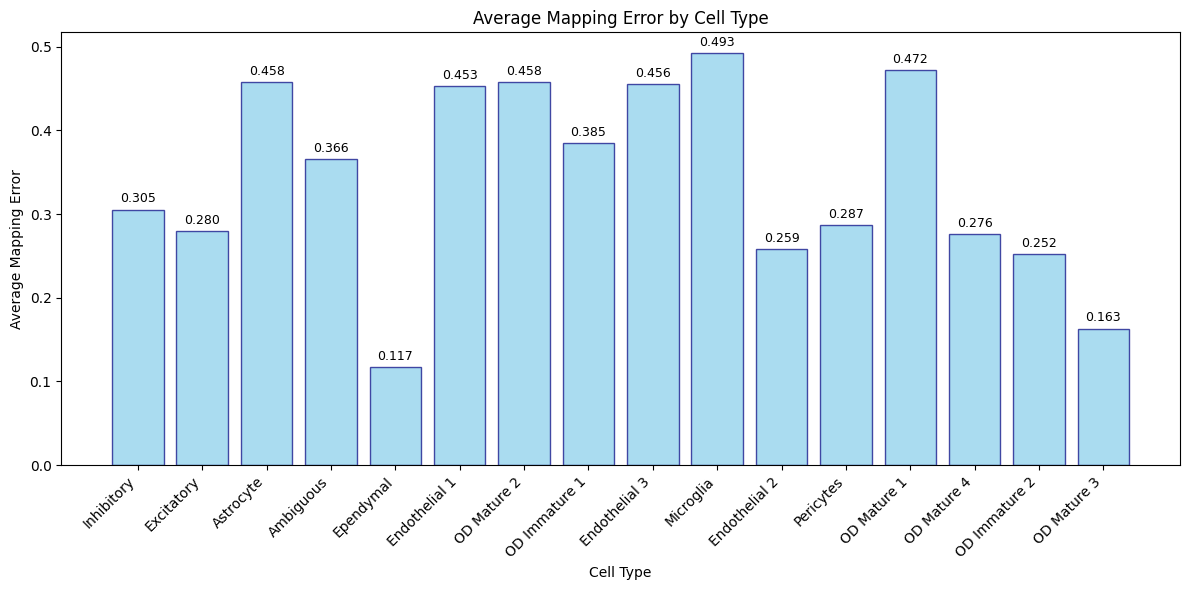


Summary:
Overall average error: 0.342
Standard deviation: 0.113
Min error: 0.117 (Ependymal)
Max error: 0.493 (Microglia)


In [15]:
# Calculate mapping errors for each cell type
cell_type_errors = {}

for cell_type, ad_c_celltype in cell_type_results.items():
    print(f"Calculating error for {cell_type}...")
    
    # Get cells of this type from original single-cell data
    sc_cells_mask = ad_sc.obs['Cell_type'] == cell_type
    sc_cells_indices = np.where(sc_cells_mask)[0]
    
    # Get original spatial coordinates for these cells
    sc_coords = ad_sc.obsm['spatial'][sc_cells_mask]
    
    # Get mapped coordinates from the result
    mapped_coords = ad_c_celltype.obsm['spatial']
    
    # Calculate Euclidean distances between original and mapped positions
    # We need to match cells by their names/indices
    total_error = 0
    matched_cells = 0
    
    for i, sc_idx in enumerate(sc_cells_indices):
        sc_name = ad_sc.obs_names[sc_idx]
        
        # Find this cell in the mapped result
        if sc_name in ad_c_celltype.obs_names:
            matched_indices = np.where(ad_c_celltype.obs_names == sc_name)[0]
            if len(matched_indices) > 0:
                mapped_idx = matched_indices[0]
                
                # Calculate Euclidean distance between original and mapped positions
                original_pos = ad_sc.obsm['spatial'][sc_idx]
                mapped_pos = ad_c_celltype.obsm['spatial'][mapped_idx]
                
                error = np.sqrt(np.sum((original_pos - mapped_pos)**2))
                total_error += error
                matched_cells += 1
    
    # Normalize by number of cells
    if matched_cells > 0:
        avg_error = total_error / matched_cells
        cell_type_errors[cell_type] = avg_error
        print(f"  Average error for {cell_type}: {avg_error:.3f} (based on {matched_cells} cells)")
    else:
        cell_type_errors[cell_type] = 0
        print(f"  No matched cells found for {cell_type}")

# Create bar plot
plt.figure(figsize=(12, 6))
cell_types = np.array(list(cell_type_errors.keys()))
errors = np.array(list(cell_type_errors.values()))

I = np.array([np.where(cell_types == ct)[0][0] for ct in cell_type_counts.index])

bars = plt.bar(cell_types[I], errors[I], alpha=0.7, color='skyblue', edgecolor='navy')
plt.xlabel('Cell Type')
plt.ylabel('Average Mapping Error')
plt.title('Average Mapping Error by Cell Type')
plt.xticks(rotation=45, ha='right')

# Add value labels on bars
for bar, error in zip(bars, errors[I]):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + max(errors)*0.01,
             f'{error:.3f}', ha='center', va='bottom', fontsize=9)


plt.tight_layout()
plt.show()

# Print summary statistics
print(f"\nSummary:")
print(f"Overall average error: {np.mean(list(cell_type_errors.values())):.3f}")
print(f"Standard deviation: {np.std(list(cell_type_errors.values())):.3f}")
print(f"Min error: {min(cell_type_errors.values()):.3f} ({min(cell_type_errors, key=cell_type_errors.get)})")
print(f"Max error: {max(cell_type_errors.values()):.3f} ({max(cell_type_errors, key=cell_type_errors.get)})")

In [16]:
enable_save = True

In [27]:
# Calculate mapping errors for each cell type
cell_type_errors = {}
cell_type_null_distributions = {}
cell_type_pvalues = {}

n_permutations = 100
np.random.seed(0)
for cell_type, ad_c_celltype in cell_type_results.items():
    print(f"Calculating error for {cell_type}...")
    
    # Get cells of this type from original single-cell data
    sc_cells_mask = ad_sc.obs['Cell_type'] == cell_type
    sc_cells_indices = np.where(sc_cells_mask)[0]
    
    # Get original spatial coordinates for these cells
    sc_coords = ad_sc.obsm['spatial'][sc_cells_mask]
    
    # Get mapped coordinates from the result
    mapped_coords = ad_c_celltype.obsm['spatial']
    n_mapped_spots = mapped_coords.shape[0]
    # Calculate Euclidean distances between original and mapped positions
    # We need to match cells by their names/indices
    total_error = 0
    matched_cells = 0
    
    for i, sc_idx in enumerate(sc_cells_indices):
        sc_name = ad_sc.obs_names[sc_idx]
        
        # Find this cell in the mapped result
        if sc_name in ad_c_celltype.obs_names:
            matched_indices = np.where(ad_c_celltype.obs_names == sc_name)[0]
            if len(matched_indices) > 0:
                mapped_idx = matched_indices[0]
                
                # Calculate Euclidean distance between original and mapped positions
                original_pos = ad_sc.obsm['spatial'][sc_idx]
                mapped_pos = ad_c_celltype.obsm['spatial'][mapped_idx]
                
                error = np.sqrt(np.sum((original_pos - mapped_pos)**2))
                total_error += error
                matched_cells += 1
    
    # Normalize by number of cells
    if matched_cells > 0:
        avg_error = total_error / matched_cells
        cell_type_errors[cell_type] = avg_error
        print(f"  Average error for {cell_type}: {avg_error:.3f} (based on {matched_cells} cells)")
        # Generate NULL DISTRIBUTION through random permutations
        print(f"  Generating null distribution with {n_permutations} permutations...")
        null_errors = []
        for perm in range(n_permutations):
            perm_total_error = 0
            perm_matched_cells = 0
            for i, sc_idx in enumerate(sc_cells_indices):
                sc_name = ad_sc.obs_names[sc_idx]
                
                if sc_name in ad_c_celltype.obs_names:
                    matched_indices = np.where(ad_c_celltype.obs_names == sc_name)[0]
                    if len(matched_indices) > 0:
                        # RANDOM assignment: randomly select a spot from all available spots
                        random_spot_idx = np.random.randint(0, n_mapped_spots)
                        
                        original_pos = ad_sc.obsm['spatial'][sc_idx]
                        random_mapped_pos = mapped_coords[random_spot_idx]
                        
                        error = np.sqrt(np.sum((original_pos - random_mapped_pos)**2))
                        perm_total_error += error
                        perm_matched_cells += 1
            
            if perm_matched_cells > 0:
                null_errors.append(perm_total_error / perm_matched_cells)
        cell_type_null_distributions[cell_type] = np.array(null_errors)
        p_value = np.mean(null_errors <= avg_error)
        cell_type_pvalues[cell_type] = p_value
    else:
        cell_type_errors[cell_type] = 0
        cell_type_null_distributions[cell_type] = np.array([])
        cell_type_pvalues[cell_type] = 1.0
        print(f"  No matched cells found for {cell_type}")


Calculating error for Microglia...
  Average error for Microglia: 0.493 (based on 81 cells)
  Generating null distribution with 100 permutations...
Calculating error for Astrocyte...
  Average error for Astrocyte: 0.458 (based on 488 cells)
  Generating null distribution with 100 permutations...
Calculating error for Endothelial 1...
  Average error for Endothelial 1: 0.453 (based on 206 cells)
  Generating null distribution with 100 permutations...
Calculating error for Endothelial 2...
  Average error for Endothelial 2: 0.259 (based on 37 cells)
  Generating null distribution with 100 permutations...
Calculating error for Endothelial 3...
  Average error for Endothelial 3: 0.456 (based on 90 cells)
  Generating null distribution with 100 permutations...
Calculating error for Pericytes...
  Average error for Pericytes: 0.287 (based on 36 cells)
  Generating null distribution with 100 permutations...
Calculating error for Ambiguous...
  Average error for Ambiguous: 0.366 (based on 520 

In [29]:
cell_type_errors_e = cell_type_errors.copy()
cell_type_null_distributions_e = cell_type_null_distributions.copy()

### figb

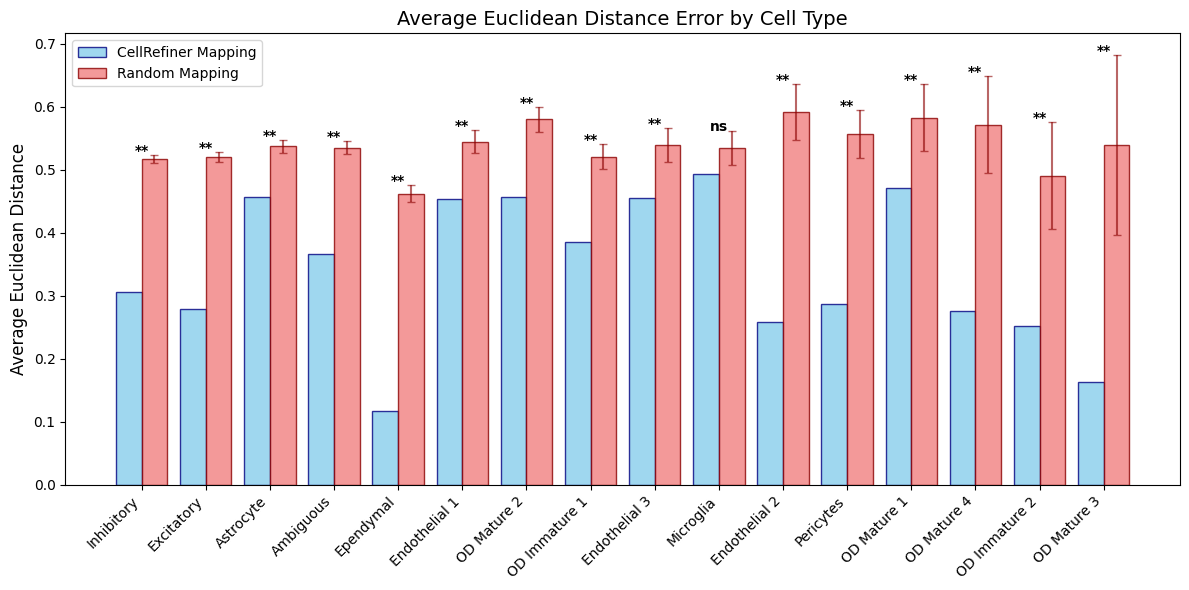

In [28]:
fig,ax = plt.subplots(figsize=(12, 6))
cell_types = np.array(list(cell_type_errors.keys()))
errors = np.array(list(cell_type_errors.values()))

null_means = np.array([np.mean(cell_type_null_distributions[ct]) if len(cell_type_null_distributions[ct]) > 0 else 0 
                       for ct in cell_types[I]])
null_stds = np.array([np.std(cell_type_null_distributions[ct]) if len(cell_type_null_distributions[ct]) > 0 else 0 
                      for ct in cell_types[I]])
x = np.arange(len(cell_types[I]))
width = 0.4

bars1 = ax.bar(x - width/2, errors[I], width, label='CellRefiner Mapping', 
               alpha=0.8, color='skyblue', edgecolor='navy')
bars2 = ax.bar(x + width/2, null_means, width, label='Random Mapping', 
               alpha=0.8, color='lightcoral', edgecolor='darkred')
ax.errorbar(x + width/2, null_means, yerr=null_stds, fmt='none', 
            ecolor='darkred', capsize=3, alpha=0.6)

# ax.set_xlabel('Cell Type', fontsize=12)
ax.set_ylabel('Average Euclidean Distance', fontsize=12)
ax.set_title(f'Average Euclidean Distance Error by Cell Type', fontsize=14)
ax.set_xticks(x)
ax.set_xticklabels(cell_types[I], rotation=45, ha='right')
ax.legend()
# ax.grid(axis='y', alpha=0.3)

# Add significance stars
error_sort = errors[I]
for i, ct in enumerate(cell_types[I]):
    p_val = cell_type_pvalues[ct]
    # if p_val < 0.001:
    #     sig = '***'
    # el
    if p_val < 0.01:
        sig = '**'
    elif p_val < 0.05:
        sig = '*'
    else:
        sig = 'ns'
    
    y_pos = max(error_sort[i], null_means[i]) + null_stds[i]
    ax.text(i, y_pos, sig, ha='center', fontsize=10, fontweight='bold')


plt.tight_layout()
if enable_save:
    plt.savefig('rare_cell_type_euclidean_distance.png', dpi=500, bbox_inches='tight')
plt.show()

In [20]:
import ot
n_permutations = 100
cell_type_errors = {}
cell_type_null_distributions = {}
cell_type_pvalues = {}
np.random.seed(0)
for cell_type, ad_c_celltype in cell_type_results.items():
    print(f"Calculating Wasserstein distance for {cell_type}...")
    
    sc_cells_mask = ad_sc.obs['Cell_type'] == cell_type
    sc_cells_indices = np.where(sc_cells_mask)[0]
    
    original_positions = ad_sc.obsm['spatial'][sc_cells_mask]
    
    # Get mapped positions
    mapped_positions = []
    for sc_idx in sc_cells_indices:
        sc_name = ad_sc.obs_names[sc_idx]
        if sc_name in ad_c_celltype.obs_names:
            matched_indices = np.where(ad_c_celltype.obs_names == sc_name)[0]
            if len(matched_indices) > 0:
                mapped_idx = matched_indices[0]
                mapped_positions.append(ad_c_celltype.obsm['spatial'][mapped_idx])
    
    mapped_positions = np.array(mapped_positions)
    
    if len(mapped_positions) > 0:
        n_mapped = mapped_positions.shape[0]
        n_orig = original_positions.shape[0]
        # Uniform weights for both distributions
        weights_original = np.ones(n_orig) / n_orig
        weights_mapped = np.ones(n_mapped) / n_mapped
        
        # Calculate cost matrix (pairwise Euclidean distances)
        cost_matrix = ot.dist(original_positions, mapped_positions, metric='euclidean')
        
        # Calculate ACTUAL Wasserstein distance (2-Wasserstein with squared distances)
        actual_wd = ot.emd2(weights_original, weights_mapped, cost_matrix)
        # For 1-Wasserstein (non-squared), use: np.sqrt(actual_wd)
        cell_type_errors[cell_type] = actual_wd
        
        print(f"  Actual Wasserstein distance: {actual_wd:.3f} (based on {n_mapped} cells)")
        
        # Generate NULL DISTRIBUTION
        print(f"  Generating null distribution with {n_permutations} permutations...")
        null_errors = []
        all_mapped_coords = ad_c_celltype.obsm['spatial']
        
        for perm in range(n_permutations):
            if (perm + 1) % 100 == 0:
                print(f"    Permutation {perm + 1}/{n_permutations}")
            
            # Randomly sample positions
            random_indices = np.random.choice(len(all_mapped_coords), size=n_mapped, replace=True)
            random_positions = all_mapped_coords[random_indices]
            
            # Calculate cost matrix for random positions
            cost_matrix_null = ot.dist(original_positions, random_positions, metric='euclidean')
            
            # Calculate Wasserstein distance
            null_wd = ot.emd2(weights_original, weights_mapped, cost_matrix_null)
            null_errors.append(null_wd)
        null_errors = np.array(null_errors)
        cell_type_null_distributions[cell_type] = null_errors
        
        # Calculate p-value
        p_value = np.mean(null_errors <= actual_wd)
        cell_type_pvalues[cell_type] = p_value
        
        print(f"  Null distribution mean: {np.mean(null_errors):.3f} ± {np.std(null_errors):.3f}")
        print(f"  P-value: {p_value:.4f}")
    else:
        cell_type_errors[cell_type] = 0
        cell_type_null_distributions[cell_type] = np.array([])
        cell_type_pvalues[cell_type] = 1.0

Calculating Wasserstein distance for Microglia...
  Actual Wasserstein distance: 0.178 (based on 81 cells)
  Generating null distribution with 100 permutations...
    Permutation 100/100
  Null distribution mean: 0.111 ± 0.016
  P-value: 1.0000
Calculating Wasserstein distance for Astrocyte...
  Actual Wasserstein distance: 0.101 (based on 488 cells)
  Generating null distribution with 100 permutations...


    Permutation 100/100
  Null distribution mean: 0.060 ± 0.006
  P-value: 1.0000
Calculating Wasserstein distance for Endothelial 1...
  Actual Wasserstein distance: 0.073 (based on 206 cells)
  Generating null distribution with 100 permutations...
    Permutation 100/100
  Null distribution mean: 0.081 ± 0.009
  P-value: 0.2100
Calculating Wasserstein distance for Endothelial 2...
  Actual Wasserstein distance: 0.096 (based on 37 cells)
  Generating null distribution with 100 permutations...
    Permutation 100/100
  Null distribution mean: 0.299 ± 0.038
  P-value: 0.0000
Calculating Wasserstein distance for Endothelial 3...
  Actual Wasserstein distance: 0.141 (based on 90 cells)
  Generating null distribution with 100 permutations...
    Permutation 100/100
  Null distribution mean: 0.112 ± 0.014
  P-value: 0.9500
Calculating Wasserstein distance for Pericytes...
  Actual Wasserstein distance: 0.112 (based on 36 cells)
  Generating null distribution with 100 permutations...
    Per

### fig c

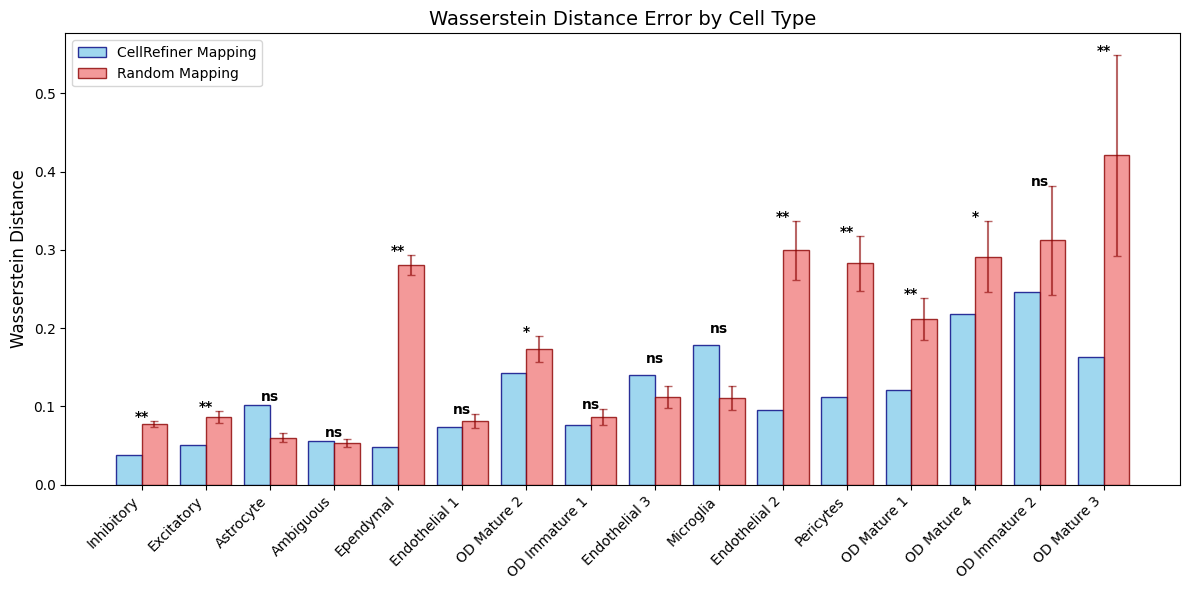

In [26]:
fig,ax = plt.subplots(figsize=(12, 6))
cell_types = np.array(list(cell_type_errors.keys()))
errors = np.array(list(cell_type_errors.values()))

I = np.array([np.where(cell_types == ct)[0][0] for ct in cell_type_counts.index])
null_means = np.array([np.mean(cell_type_null_distributions[ct]) if len(cell_type_null_distributions[ct]) > 0 else 0 
                       for ct in cell_types[I]])
null_stds = np.array([np.std(cell_type_null_distributions[ct]) if len(cell_type_null_distributions[ct]) > 0 else 0 
                      for ct in cell_types[I]])
x = np.arange(len(cell_types[I]))
width = 0.4

bars1 = ax.bar(x - width/2, errors[I], width, label='CellRefiner Mapping', 
               alpha=0.8, color='skyblue', edgecolor='navy')
bars2 = ax.bar(x + width/2, null_means, width, label='Random Mapping', 
               alpha=0.8, color='lightcoral', edgecolor='darkred')
ax.errorbar(x + width/2, null_means, yerr=null_stds, fmt='none', 
            ecolor='darkred', capsize=3, alpha=0.6)

# ax.set_xlabel('Cell Type', fontsize=12)
ax.set_ylabel('Wasserstein Distance', fontsize=12)
ax.set_title(f'Wasserstein Distance Error by Cell Type', fontsize=14)
ax.set_xticks(x)
ax.set_xticklabels(cell_types[I], rotation=45, ha='right')
ax.legend()
# ax.grid(axis='y', alpha=0.3)

# Add significance stars
error_sort = errors[I]
for i, ct in enumerate(cell_types[I]):
    p_val = cell_type_pvalues[ct]
    # if p_val < 0.001:
    #     sig = '***'
    # el
    if p_val < 0.01:
        sig = '**'
    elif p_val < 0.05:
        sig = '*'
    else:
        sig = 'ns'
    
    y_pos = max(error_sort[i], null_means[i]) + null_stds[i]
    ax.text(i, y_pos, sig, ha='center', fontsize=10, fontweight='bold')
plt.tight_layout()
if enable_save:
    plt.savefig('rare_cell_type_wasserstein_distance.png', dpi=500, bbox_inches='tight')
plt.show()